In [1]:
!pip install snowflake-connector-python pandas scikit-learn

In [2]:
import snowflake.connector
import pandas as pd

con=snowflake.connector.connect(
    user='Shivaji',
    password='Shivaji11042007',
    account='PLFONYJ-PV16555',
    database='insurance',
    schema='PUBLIC',
    warehouse='COMPUTE_WH'
)

In [3]:
query='select * from insurancedb'
df=pd.read_sql(query,con)

/tmp/ipykernel_57739/390651191.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(query,con)


In [4]:
df


,MONTHS_AS_CUSTOMER,AGE,POLICY_NUMBER,POLICY_BIND_DATE,POLICY_STATE,POLICY_CSL,POLICY_DEDUCTABLE,POLICY_ANNUAL_PREMIUM,UMBRELLA_LIMIT,INSURED_ZIP,...,POLICE_REPORT_AVAILABLE,TOTAL_CLAIM_AMOUNT,INJURY_CLAIM,PROPERTY_CLAIM,VEHICLE_CLAIM,AUTO_MAKE,AUTO_MODEL,AUTO_YEAR,FRAUD_REPORTED,_C39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,True,None
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,True,None
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,False,None
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,True,None
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,False,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,False,None
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,False,None
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,False,None
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,False,None


In [5]:
df.isnull().sum()

,0
MONTHS_AS_CUSTOMER,0
AGE,0
POLICY_NUMBER,0
POLICY_BIND_DATE,0
POLICY_STATE,0
POLICY_CSL,0
POLICY_DEDUCTABLE,0
POLICY_ANNUAL_PREMIUM,0
UMBRELLA_LIMIT,0
INSURED_ZIP,0


In [6]:
df.drop(columns=['_C39'],inplace=True)

In [7]:
df.isna().sum()

,0
MONTHS_AS_CUSTOMER,0
AGE,0
POLICY_NUMBER,0
POLICY_BIND_DATE,0
POLICY_STATE,0
POLICY_CSL,0
POLICY_DEDUCTABLE,0
POLICY_ANNUAL_PREMIUM,0
UMBRELLA_LIMIT,0
INSURED_ZIP,0


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

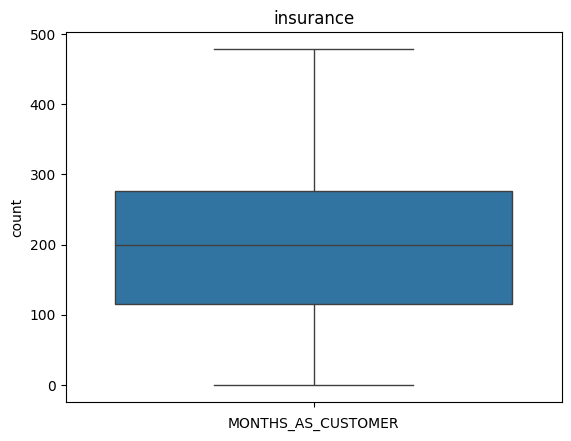

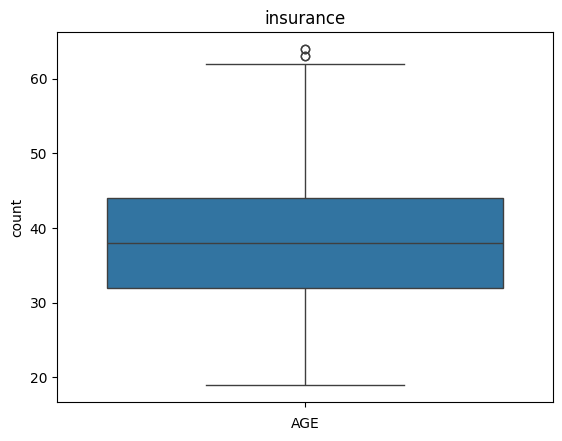

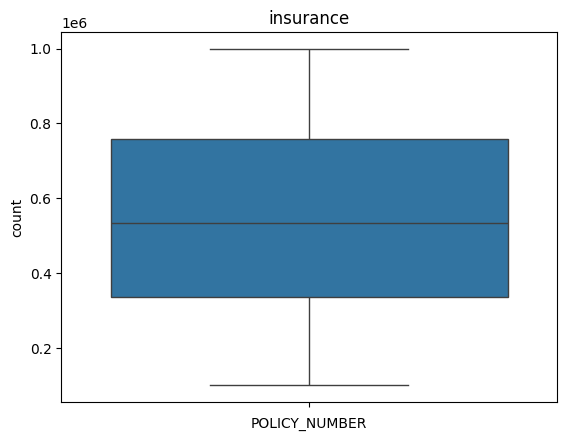

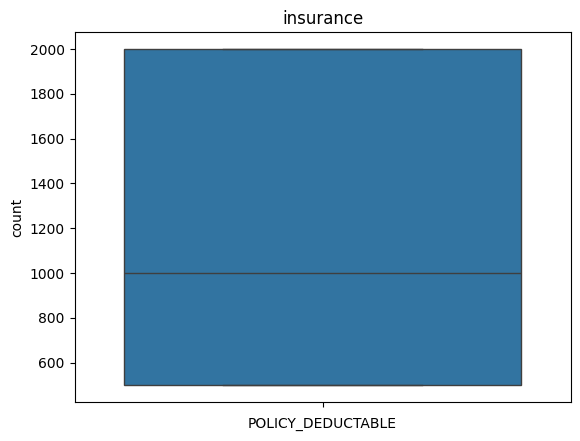

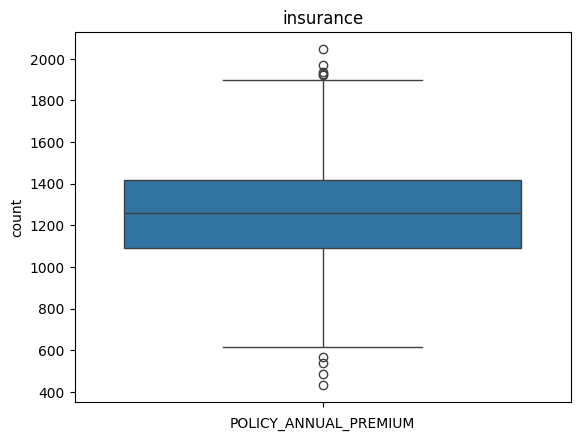

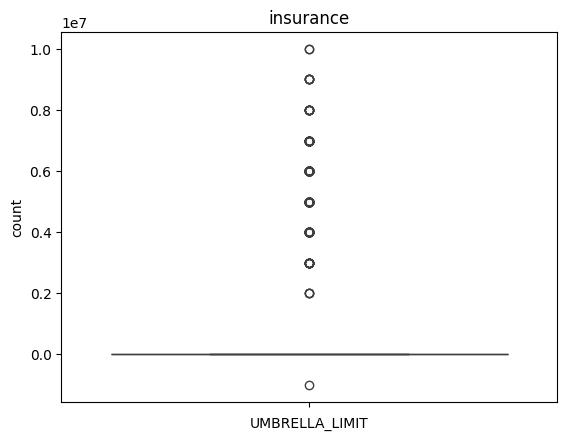

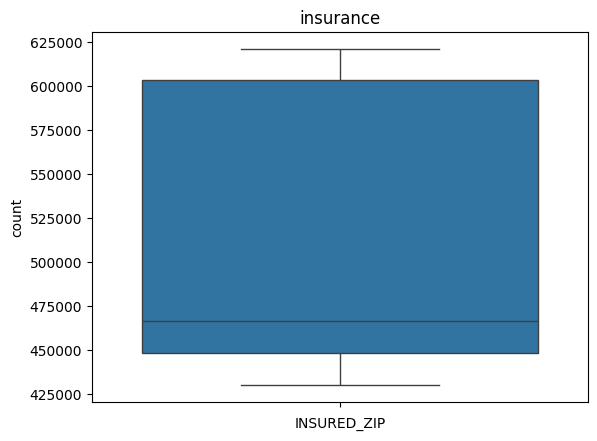

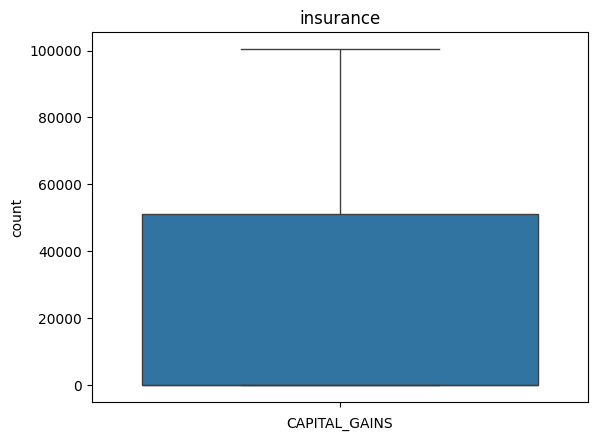

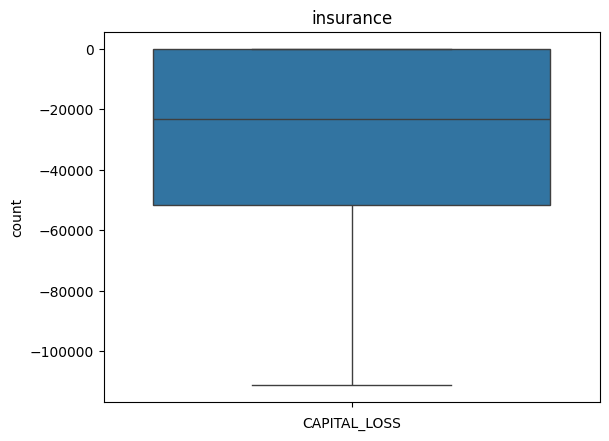

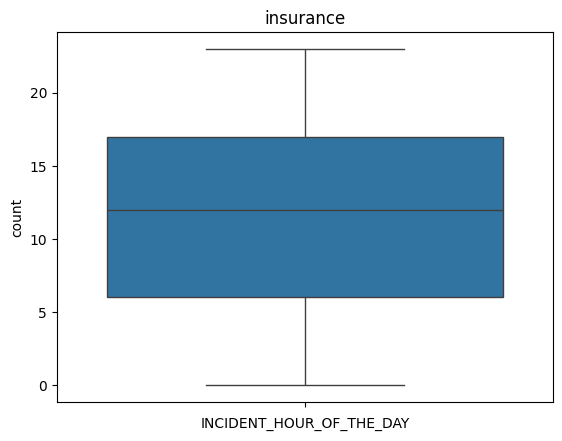

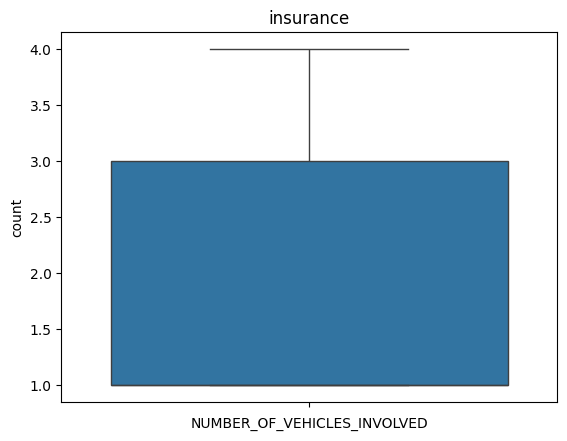

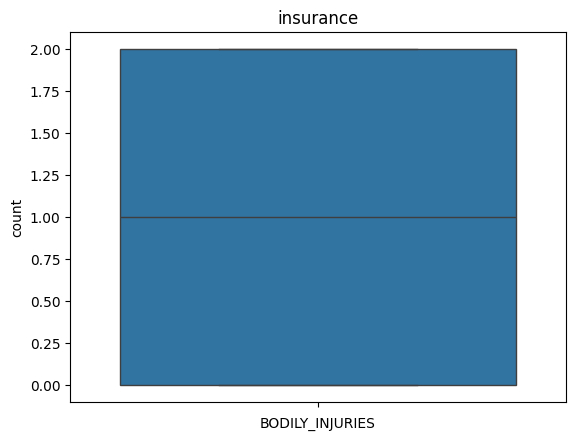

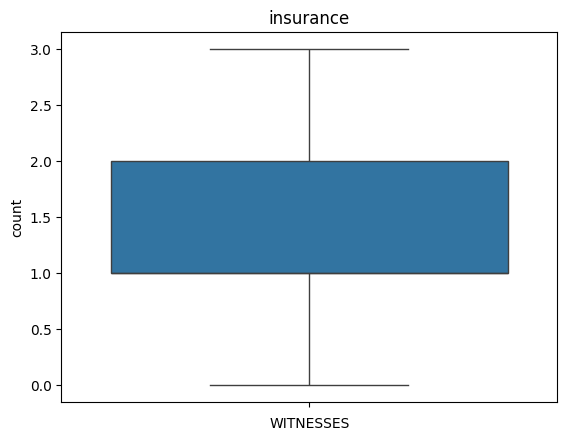

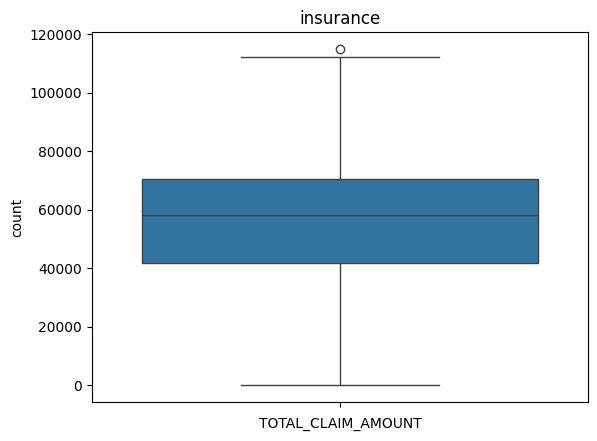

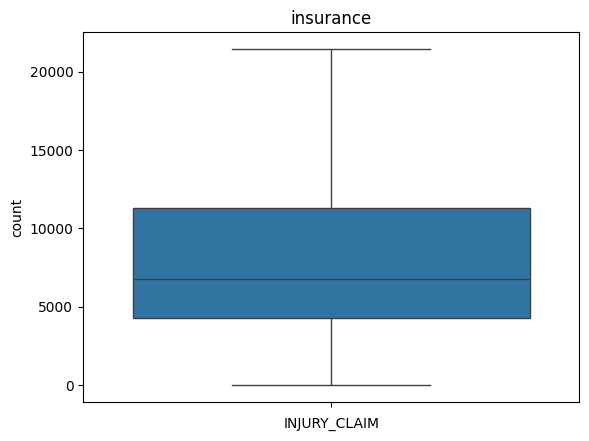

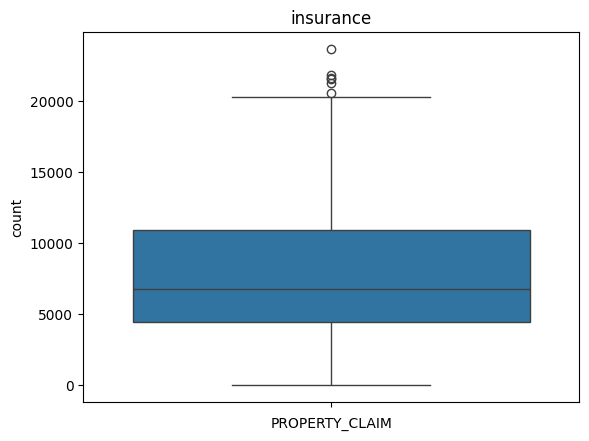

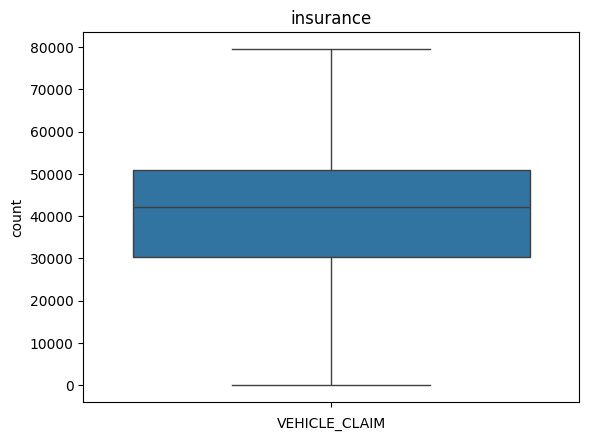

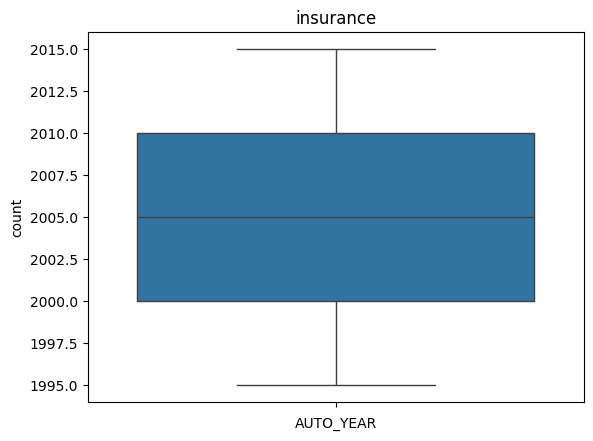

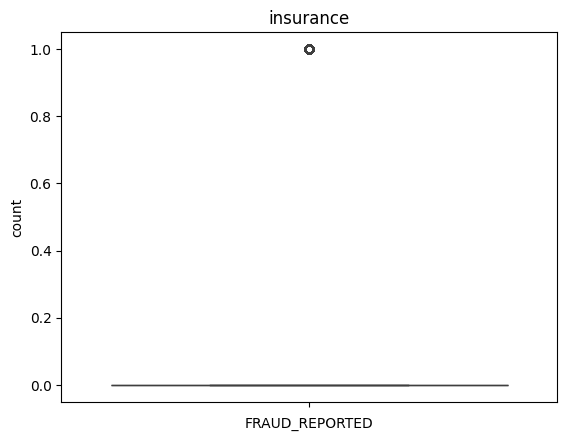

In [9]:
for i in df.columns:
  if df[i].dtypes!="object":
    sns.boxplot(df[i])
    plt.title("insurance")
    plt.xlabel(i)
    plt.ylabel("count")
    plt.show()

In [10]:
cols=['AGE','POLICY_ANNUAL_PREMIUM','TOTAL_CLAIM_AMOUNT','PROPERTY_CLAIM','FRAUD_REPORTED']


In [11]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer(method='yeo-johnson')
for i in cols:
    if df[i].dtypes == "object":
      df[i]=pt.fit_transform(df[[i]])
df



,MONTHS_AS_CUSTOMER,AGE,POLICY_NUMBER,POLICY_BIND_DATE,POLICY_STATE,POLICY_CSL,POLICY_DEDUCTABLE,POLICY_ANNUAL_PREMIUM,UMBRELLA_LIMIT,INSURED_ZIP,...,WITNESSES,POLICE_REPORT_AVAILABLE,TOTAL_CLAIM_AMOUNT,INJURY_CLAIM,PROPERTY_CLAIM,VEHICLE_CLAIM,AUTO_MAKE,AUTO_MODEL,AUTO_YEAR,FRAUD_REPORTED
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,2,YES,71610,6510,13020,52080,Saab,92x,2004,True
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,0,?,5070,780,780,3510,Mercedes,E400,2007,True
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,False
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,True
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,1,NO,6500,1300,650,4550,Accura,RSX,2009,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,1,?,87200,17440,8720,61040,Honda,Accord,2006,False
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,3,?,108480,18080,18080,72320,Volkswagen,Passat,2015,False
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,3,YES,67500,7500,7500,52500,Suburu,Impreza,1996,False
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,1,YES,46980,5220,5220,36540,Audi,A5,1998,False


In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in df.columns:
  if df[i].dtypes == "object":
    df[i]=le.fit_transform(df[i])

In [13]:
from sklearn.model_selection import train_test_split


In [14]:
x=df.iloc[:,:-1]
y=df['FRAUD_REPORTED']

In [15]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40)


In [16]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier()
dc.fit(x_train,y_train)
y_pred=dc.predict(x_test)

In [17]:
from sklearn.metrics import accuracy_score
print("Accuracy Score",accuracy_score(y_test,y_pred)*100)

Accuracy Score 77.5


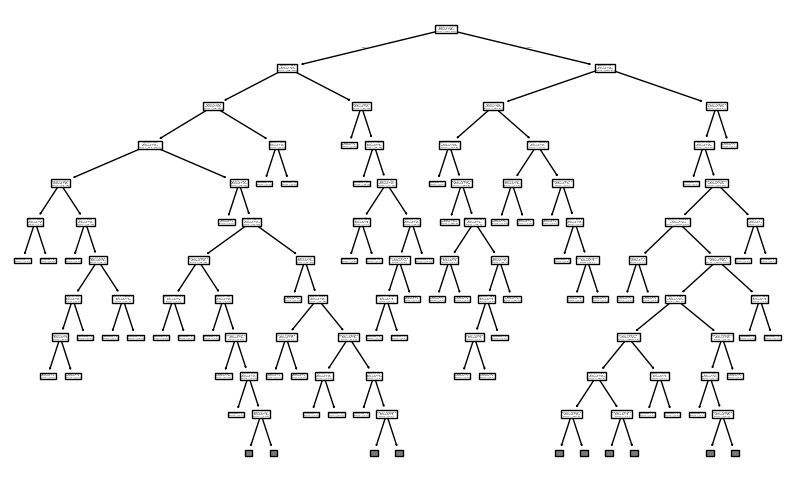

In [18]:
from sklearn import tree
fig=plt.figure(figsize=(10,6))
tree.plot_tree(dc,max_depth=10)
plt.show()

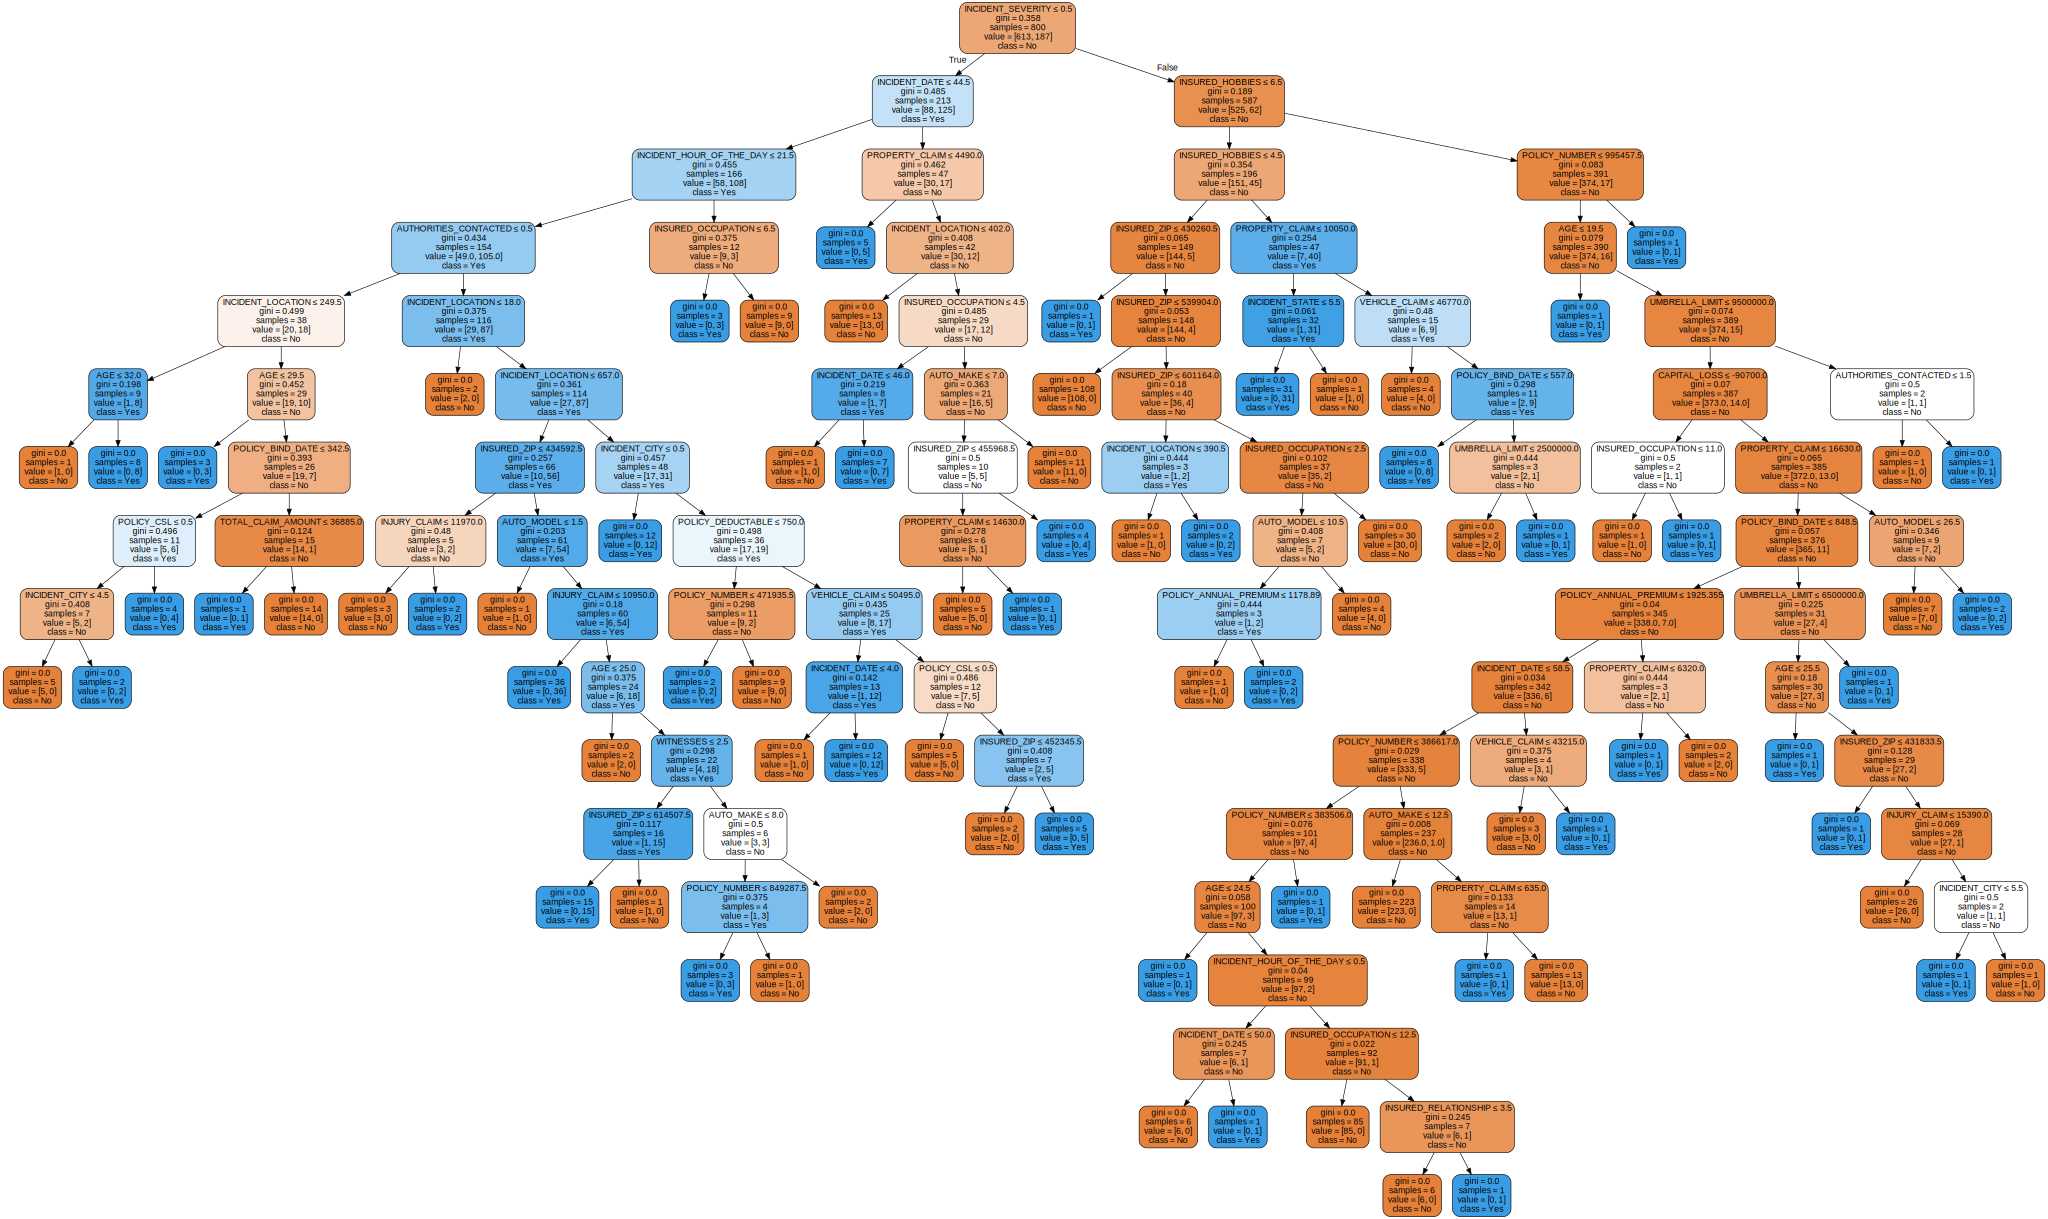

In [19]:
from sklearn.tree import export_graphviz
import graphviz

graph=export_graphviz(
    dc,
    out_file=None,
    feature_names=x.columns,
    class_names=['No','Yes'],
    filled=True,
    rounded=True,
    special_characters=True
)

gr=graphviz.Source(graph)
gr